In [1]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import os
import sys
#sys.path.append('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search/')
sys.path.append('/Users/albertolsen/Documents/Stud.Polit./9. semester/Dynamic Programming/Exam/termpaper_dynprog/Job Search/')
#print(os.getcwd())
#print(os.listdir("/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search"))
import Model_components as model
import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate 
import optimagic as om
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pandas as pd
import scipy.optimize as opt
from scipy.optimize import fsolve
from scipy.stats import beta
from numba import njit, vectorize


ModuleNotFoundError: No module named 'Model_components'

In [2]:
delta = 0.93
gamma = 0.9
eta = 1
k = 300
k1 = 300
k2 = 250
k3 = 200
q1 = 0.3
q2 = 0.3
lmbda = 4.9
N = 6

abar = [0, 1000]

n_a = 50
n_c = 100
T1 = 6
T2 = 18
T3 = 24
T = 44
b1= 222
b2 = 222
b3 = 114 
welfare = 90
w = 675
R = 0.01


In [3]:
params = np.array([delta, gamma, eta, k, lmbda, N])
params_multi = np.array([delta, gamma, eta, k1, k2, k3, q1, q2,lmbda, N])
institutions_pre = np.array([ n_a, n_c, T1, T2, T3, T, b1, b2, b3, welfare, w, R])
b1 = 342
b2 = 171
institutions_post = np.array([ n_a, n_c, T1, T2, T3, T, b1, b2, b3, welfare, w, R])

# Asset grid
a_grid = np.linspace(abar[0], abar[1], n_a)

# Scale asset grid to [0,1]
x = (a_grid - abar[0]) / (abar[1] - abar[0])

# Plausible right-skewed asset distribution
alpha = 1.5
beta_param = 4.0

weights = beta.pdf(x, alpha, beta_param)

# Normalize so weights sum to 1
weights = weights / weights.sum()

In [4]:

a_grid = np.linspace(abar[0], abar[1], n_a)

# Convert grid to [0,1]
x = (a_grid - abar[0]) / (abar[1] - abar[0])

# Bin boundaries halfway between grid points
edges = np.empty(n_a + 1)
edges[1:-1] = (x[:-1] + x[1:]) / 2
edges[0] = 0
edges[-1] = 1

alpha = 1.5
beta_param = 4.0

# Probability mass in each bin
weights = np.diff(beta.cdf(edges, alpha, beta_param))

weights /= weights.sum()

In [5]:
S, V_emp, V_unemp, c_emp, c_unemp, Vss_emp, Vss_uemp, css_emp, css_uemp, survival, benefits = model.SolveModel(params, institutions_pre, abar)

Optimal consumption of assets solved in 280 iterations, using 0.10032 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09561 seconds


In [6]:
#S, V_emp, V_unemp, c_emp, c_unemp, Vss_emp, Vss_uemp, css_emp, css_uemp, survival, benefits = model.SolveModel(delta, gamma, eta, k, lmbda, N abar, n_a, n_c, T1, T2, T3, T , b1, b2, b3, welfare, w, R)

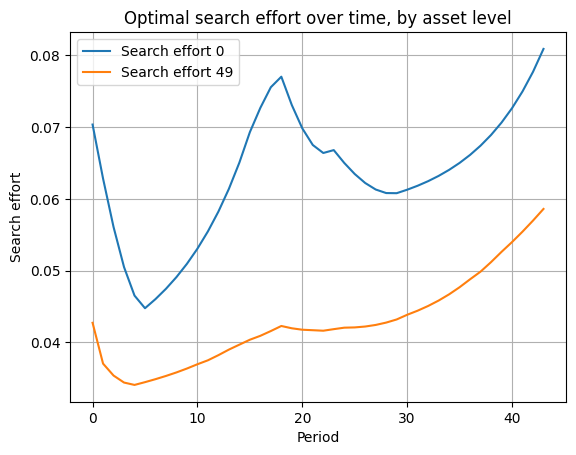

In [7]:
plt.plot(S[0,:-1], label="Search effort 0")
plt.plot(S[49,:-1], label="Search effort 49")
#plt.plot(S[10,:], label="Search")
plt.xlabel("Period")
plt.ylabel("Search effort")
plt.title("Optimal search effort over time, by asset level")
plt.legend()
plt.grid(True)
plt.show()

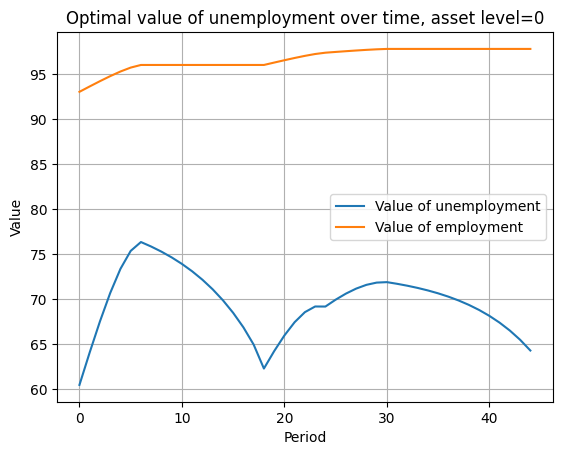

In [8]:
plt.plot(V_unemp[0,:], label="Value of unemployment")
plt.plot(V_emp[0,:], label="Value of employment")
#plt.plot(S[10,:], label="Search")
plt.xlabel("Period")
plt.ylabel("Value")
plt.title("Optimal value of unemployment over time, asset level=0")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
moments = model.simulate_moments(params, institutions_pre, institutions_post, abar, weights)
timevec = np.arange((len(moments))/2)*15 + 15

Optimal consumption of assets solved in 280 iterations, using 0.11339 seconds
Optimal consumption of assets solved in 275 iterations, using 0.0972 seconds
Optimal consumption of assets solved in 280 iterations, using 0.10549 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09619 seconds


In [10]:
# Create target (empirical moments) and covariance matrix
target, cov = model.matchingMoments()

# Create weighting function
W = np.linalg.inv(cov)



In [11]:
# Create SSE, distance measure
SSE = model.sse(params, target, W, institutions_pre, institutions_post, abar, weights)

Optimal consumption of assets solved in 280 iterations, using 0.11509 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09482 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09705 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09364 seconds


In [12]:
print(f'SSE (Goodness of Fit): {SSE}')

SSE (Goodness of Fit): 1644.0815091963711


In [13]:
def split_half(arr):
    mid = len(arr) // 2
    return arr[:mid], arr[mid:]

pre, post = split_half(moments)


emp_pre, emp_post = split_half(target)


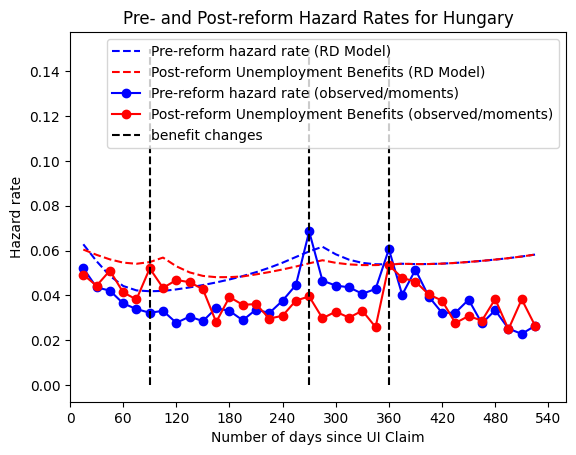

In [14]:
plt.plot(timevec, pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec, post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec, emp_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec, emp_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[6*15, 18*15, 24*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

In [15]:
fixed_params = params

In [16]:
sse1 = model.sse(fixed_params, target, W, institutions_pre, institutions_post, abar, weights)

Optimal consumption of assets solved in 280 iterations, using 0.1456 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09695 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09643 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09447 seconds


In [17]:
params_full = pd.DataFrame(
    data={"value":[0.93, 0.9, 1, 300, 4.9, 6]},
    index=["delta", "gamma", "eta", "k", "lmbda", "N"]
    )

In [18]:
params_full

,value
delta,0.93
gamma,0.90
eta,1.00
k,300.00
lmbda,4.90
N,6.00


In [19]:
smm_object = model.smm(params_full.copy(), target, W, institutions_pre, institutions_post, abar, weights)

In [20]:
params2 = pd.DataFrame(
    data={"value":[0.3],
    "lower_bound" : [0.01],
    "upper_bound" : [2]},
    index=["gamma"],
    )

In [21]:
params2

,value,lower_bound,upper_bound
gamma,0.3,0.01,2


In [22]:
print(f'GMM SSE for gamma=0.3: {smm_object.sse(params2)}')

Optimal consumption of assets solved in 280 iterations, using 0.10143 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09245 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09496 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09251 seconds
GMM SSE for gamma=0.3: 8847.54081599763


In [23]:
res = om.minimize(criterion=smm_object.sse, params=params2, algorithm='scipy_lbfgsb', )

Optimal consumption of assets solved in 280 iterations, using 0.10332 seconds


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


Optimal consumption of assets solved in 275 iterations, using 0.09753 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09759 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09402 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09719 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09412 seconds
Optimal consumption of assets solved in 280 iterations, using 0.0966 seconds
Optimal consumption of assets solved in 275 iterations, using 0.10731 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09575 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09439 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09687 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09374 seconds
Optimal consumption of assets solved in 280 iterations, using 0.10865 seconds
Optimal consumption of assets solved in 275 iterations, using 0.0

In [24]:
print(f'Optimized gamma parameter: {res.params}')
print(f'Objective function(SSE) at optimized gamma (minimum): {res.criterion}')

Optimized gamma parameter:           value  lower_bound  upper_bound
gamma  0.780626         0.01            2
Objective function(SSE) at optimized gamma (minimum): 340.35865634263973


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning: The criterion attribute is deprecated. Use the fun attribute instead.
  warnings.warn(msg, FutureWarning)


In [25]:
smm_object.params_full.update(res.params)
print(smm_object.params_full)

            value
delta    0.930000
gamma    0.780626
eta      1.000000
k      300.000000
lmbda    4.900000
N        6.000000


In [26]:
params_rd = pd.DataFrame(
    data={"value":params[:5],
    "lower_bound" : [0.01, 1e-2, 0.01, 1e-5, 0.01],
    "upper_bound" : [0.95, 2, 15, 2000, 15]},
    index=["delta", "gamma", "eta", "k", "lmbda"],
    )

In [27]:
params_rd

,value,lower_bound,upper_bound
delta,0.93,0.01000,0.95
gamma,0.90,0.01000,2.00
eta,1.00,0.01000,15.00
k,300.00,0.00001,2000.00
lmbda,4.90,0.01000,15.00


In [28]:
print(f'SMM SSE for params_rd: {smm_object.sse(params_rd)}')


Optimal consumption of assets solved in 280 iterations, using 0.10697 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09547 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09696 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09782 seconds
SMM SSE for params_rd: 1644.0815091963711


In [ ]:
res_rd = om.minimize(criterion=smm_object.sse, params=params_rd, algorithm='scipy_lbfgsb', )

Optimal consumption of assets solved in 280 iterations, using 0.10573 seconds


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


Optimal consumption of assets solved in 275 iterations, using 0.10109 seconds
Optimal consumption of assets solved in 280 iterations, using 0.1004 seconds
Optimal consumption of assets solved in 275 iterations, using 0.0958 seconds
Optimal consumption of assets solved in 280 iterations, using 0.10783 seconds
Optimal consumption of assets solved in 275 iterations, using 0.10311 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09981 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09766 seconds
Optimal consumption of assets solved in 280 iterations, using 0.12682 seconds
Optimal consumption of assets solved in 275 iterations, using 0.14176 seconds
Optimal consumption of assets solved in 280 iterations, using 0.1009 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09659 seconds
Optimal consumption of assets solved in 280 iterations, using 0.0987 seconds
Optimal consumption of assets solved in 275 iterations, using 0.1015

In [ ]:
print(f'Optimized parameters: {res_rd.params}')
print(f'Objective function(SSE) at optimized parameters: {res_rd.criterion}')

Optimized parameters:             value  lower_bound  upper_bound
delta    0.509674      0.01000         0.95
gamma    1.371858      0.01000         2.00
eta      4.198733      0.01000        15.00
k      297.341531      0.00001      2000.00
lmbda   10.082923      0.01000        15.00
Objective function(SSE) at optimized parameters: 288.39146557192566


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning: The criterion attribute is deprecated. Use the fun attribute instead.
  warnings.warn(msg, FutureWarning)


In [ ]:
fig = om.criterion_plot(res_rd)
fig

In [ ]:
res_rd.params

,value,lower_bound,upper_bound
delta,0.509674,0.01000,0.95
gamma,1.371858,0.01000,2.00
eta,4.198733,0.01000,15.00
k,297.341531,0.00001,2000.00
lmbda,10.082923,0.01000,15.00


In [ ]:
opt =res_rd.params

In [ ]:
#insert params_rd on first 5 columns of params
params_opt = params
params_opt[:5] = res_rd.params['value']
params_opt

array([  0.50967409,   1.37185833,   4.19873294, 297.34153055,
        10.08292263,   6.        ])

In [ ]:
moments = model.simulate_moments(params_opt, institutions_pre, institutions_post, abar, weights)
opt_pre, opt_post = split_half(moments)


opt_emp_pre, opt_emp_post = split_half(target)




Optimal consumption of assets solved in 32 iterations, using 0.04053 seconds
Optimal consumption of assets solved in 32 iterations, using 0.02862 seconds
Optimal consumption of assets solved in 32 iterations, using 0.02954 seconds
Optimal consumption of assets solved in 32 iterations, using 0.03243 seconds


In [ ]:
sse_opt = model.sse(params_opt, target, W, institutions_pre, institutions_post, abar, weights)
print(f'SSE (Goodness of Fit) for optimized parameters: {sse_opt}')

Optimal consumption of assets solved in 32 iterations, using 0.02866 seconds
Optimal consumption of assets solved in 32 iterations, using 0.02277 seconds
Optimal consumption of assets solved in 32 iterations, using 0.02172 seconds
Optimal consumption of assets solved in 32 iterations, using 0.02306 seconds
SSE (Goodness of Fit) for optimized parameters: 288.39146557192566


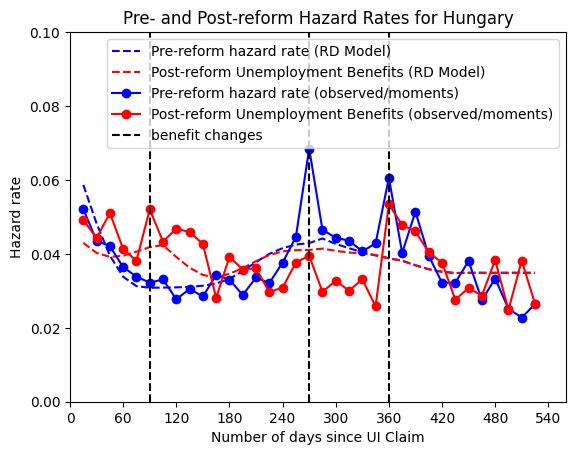

In [ ]:
plt.plot(timevec, opt_pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec, opt_post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec, opt_emp_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec, opt_emp_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.ylim(0, 0.1) # set x-axis limits to first and last element in timevec
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[6*15, 18*15, 24*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

In [ ]:
asset_indices = [0, 5, 10, 25, 50, 75, 99]

for i in asset_indices:
    plt.plot(
        timevec_H,
        S_pre[i, :35],
        label=f"A = {a_grid[i]:.0f}"
    )

plt.xlabel("Days since UI claim")
plt.ylabel("Search effort")
plt.legend()
plt.show()

NameError: name 'plt' is not defined